# 딥러닝 기초와 CNN

## 딥러닝이란?

딥러닝은 여러 층으로 구성된 인공신경망이 데이터에서 필요한 특징을 스스로 학습하도록 만드는 머신러닝 방법이다. 사람이 모든 판단 규칙을 직접 작성하는 대신, 모델이 예측 결과와 정답의 차이를 줄이는 방향으로 가중치와 편향을 반복해서 수정한다.

### CF. 머신러닝과 딥러닝 비교
- 머신러닝은 제공모델을 사용+하이퍼파라미터, 학습데이터 feature가 정해져 있어야 함.
- 딥러닝은 모델을 직접 만듦(신경망을 쌓는 과정) feature를 구분짓지 않음. 대신 학습 완료 후 feature의 개수 정도만 지정.

## 1. 딥러닝 모델이 학습되는 전체 흐름

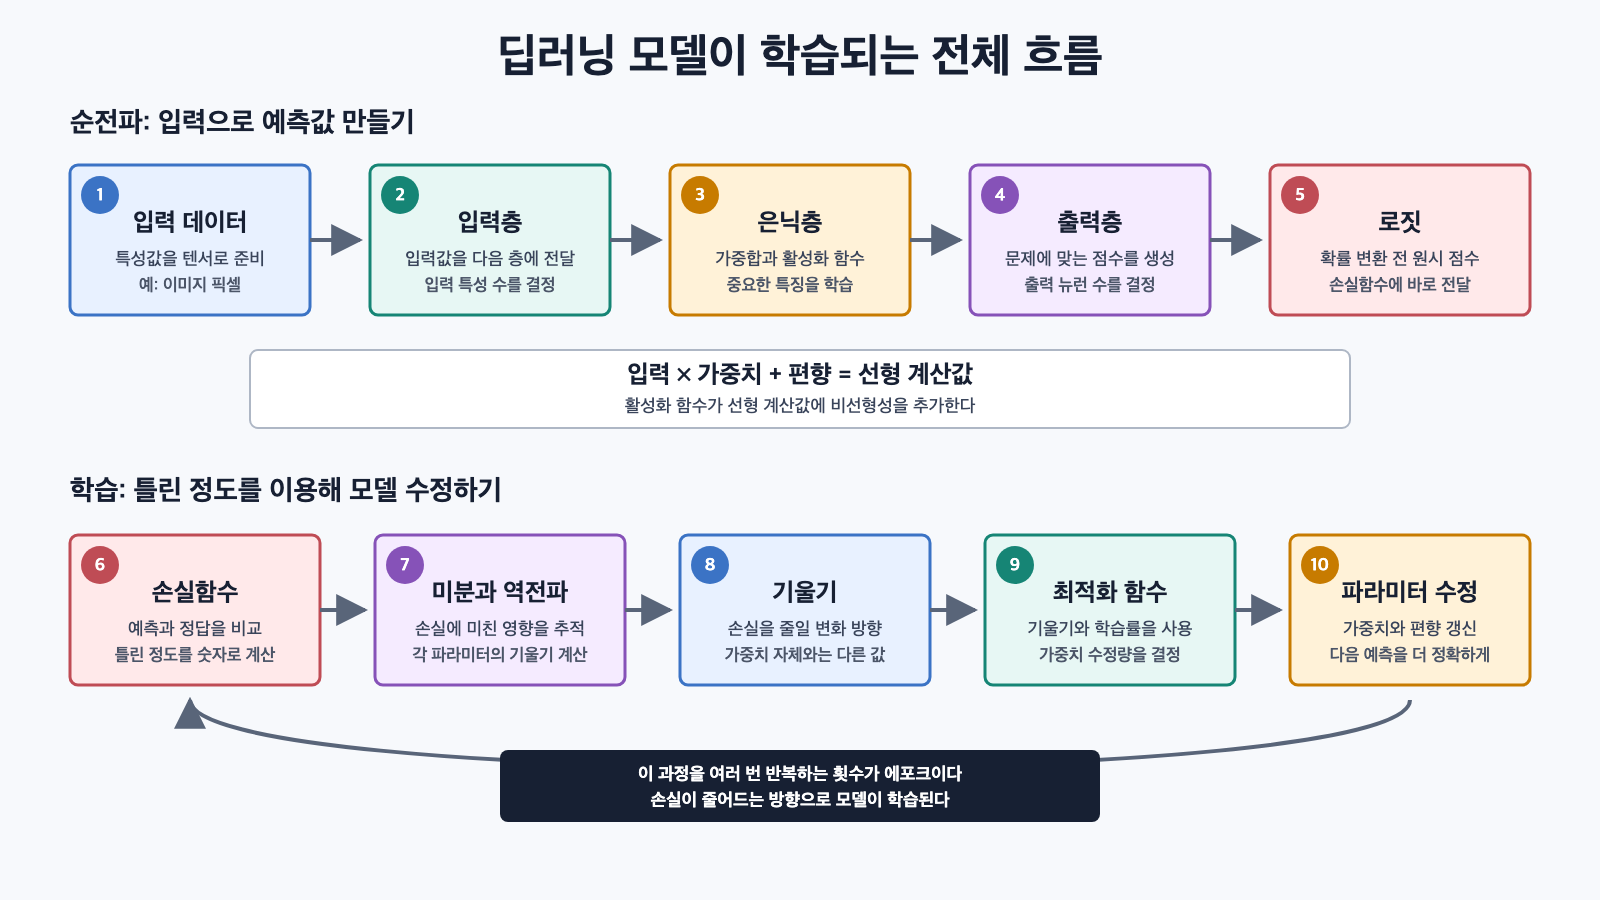

딥러닝 모델은 크게 두 단계로 동작한다.

### 순전파

입력 데이터가 모델의 각 층을 순서대로 통과해 예측값을 만드는 과정이다.

```text
입력 데이터 → 입력층 → 은닉층 → 출력층 → logits
```

### 학습

예측이 얼마나 틀렸는지 계산하고 모델의 파라미터를 수정하는 과정이다.

```text
logits와 정답 → 손실함수 → 손실값 → 역전파 → 기울기 → 최적화 → 파라미터 수정
```

모델이 학습한다는 말은 **코드 자체가 바뀐다는 뜻이 아니라 가중치와 편향의 숫자가 바뀐다는 뜻**이다.


## 2. 모델을 구성하는 핵심 요소

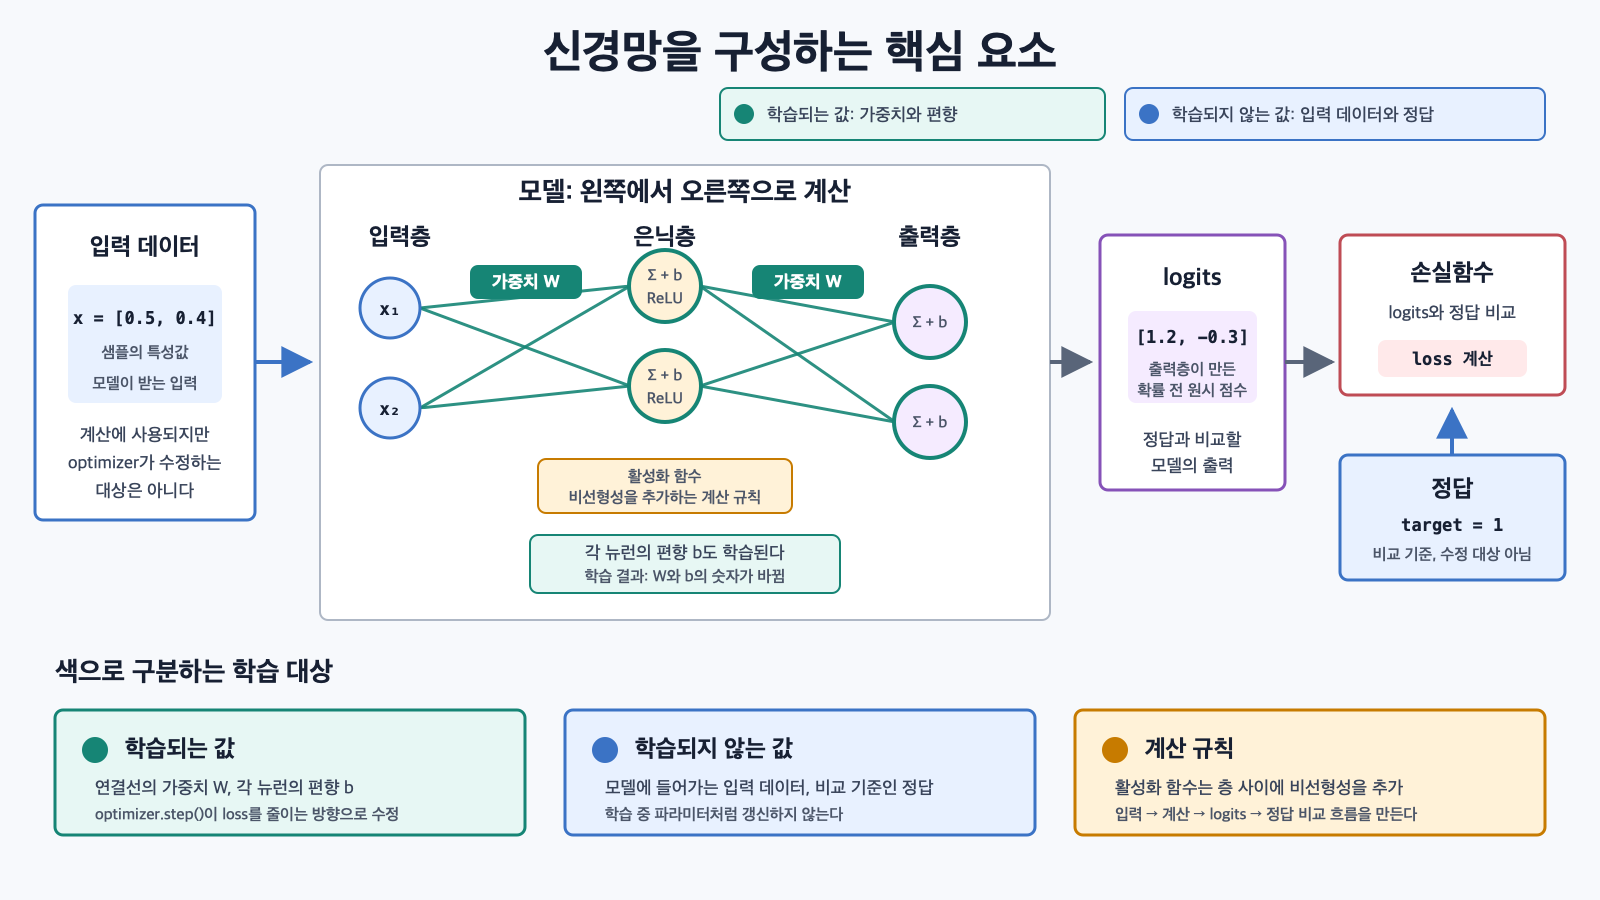

그림은 왼쪽에서 오른쪽으로 읽는다. 입력 데이터는 모델에 전달되지만 학습으로 바뀌는 값은 아니며, 층 사이의 **가중치**와 각 뉴런의 **편향**이 손실을 줄이는 방향으로 수정된다.

### 입력층

- 모델이 데이터를 처음 받아들이는 부분이다.
- 일반적으로 별도의 계산 계층이라기보다 입력 특성 수를 결정한다.
- 입력 특성이 2개라면 첫 번째 `nn.Linear`의 `in_features`도 2가 된다.

### 은닉층

- 입력층과 출력층 사이에서 특징을 변환하는 층이다.
- `Linear → ReLU`처럼 선형 계층과 활성화 함수를 함께 사용하는 경우가 많다.
- 은닉층을 여러 개 쌓으면 더 복잡한 관계를 표현할 수 있지만 항상 성능이 좋아지는 것은 아니다.

### 출력층

- 모델이 해결할 문제에 맞는 최종 출력을 만든다.
- 회귀는 예측할 값의 수, 이진 분류는 주로 1개, 다중 분류는 클래스 수만큼 출력 뉴런을 사용한다.

### 가중치

- 입력값을 얼마나 중요하게 반영할지 나타내는 학습 가능한 숫자이다.
- 입력마다 하나씩 고정되는 값이 아니라 층의 모든 연결에 행렬 형태로 존재한다.

### 편향

- 입력의 가중합에 더해지는 학습 가능한 숫자이다.
- 입력이 모두 0이어도 뉴런이 적절한 값을 만들 수 있도록 계산 기준점을 이동한다.

### 활성화 함수

- 선형 계산 결과에 비선형성을 추가한다.
- 활성화 함수가 없으면 여러 Linear 층을 쌓아도 결국 하나의 선형 계산과 비슷해진다.
- ReLU는 음수를 0으로 만들고 양수는 유지한다.

층 하나의 기본 계산은 다음과 같다.

```text
선형 계산값 = 입력 × 가중치 + 편향
은닉층 출력 = 활성화 함수(선형 계산값)
```


### 입력층부터 logits까지 코드로 확인

입력 특성 2개, 은닉 뉴런 4개, 출력 클래스 3개인 작은 모델을 만든다. 중간 계산을 함께 반환해 각 단계의 shape와 값 변화를 확인한다.


In [1]:
# 목표: 입력층, 은닉층, 출력층을 통과해 logits가 만들어지는 과정을 확인한다.

import torch
import torch.nn as nn

# 같은 초기 가중치를 사용해 실행 결과를 비교할 수 있도록 난수 seed를 고정한다.
torch.manual_seed(42)

class ReviewNet(nn.Module):
    def __init__(self):
        super().__init__()

        # 입력 특성 2개를 은닉 뉴런 4개로 변환한다.
        # weight shape는 `(출력 뉴런 4, 입력 특성 2)`, bias shape는 `(4,)`이다.
        self.hidden_layer = nn.Linear(in_features=2, out_features=4)

        # ReLU는 은닉층의 선형 계산 결과 중 음수를 0으로 만든다.
        self.activation = nn.ReLU()

        # 은닉 뉴런 4개의 값을 받아 클래스 3개의 원시 점수인 logits를 만든다.
        self.output_layer = nn.Linear(in_features=4, out_features=3)

    def forward(self, inputs):
        # 첫 번째 Linear가 `inputs @ weight.T + bias`를 계산한다.
        hidden_linear = self.hidden_layer(inputs)

        # 활성화 함수가 은닉층 표현에 비선형성을 추가한다.
        hidden_activated = self.activation(hidden_linear)

        # 출력층은 Softmax를 적용하지 않은 클래스별 logits를 만든다.
        logits = self.output_layer(hidden_activated)
        return hidden_linear, hidden_activated, logits

model = ReviewNet()

# 샘플 1개가 특성 2개를 가지므로 입력 shape는 `(1, 2)`이다.
review_inputs = torch.tensor([[0.5, 0.4]], dtype=torch.float32)

hidden_linear, hidden_activated, logits = model(review_inputs)

# Softmax는 logits를 합이 1인 클래스 확률로 바꾼다.
# 학습 손실에는 logits를 사용하고, 확률은 예측 결과를 해석할 때 확인한다.
probabilities = torch.softmax(logits, dim=1)

print("입력 shape:", tuple(review_inputs.shape))
print("은닉층 선형 계산 shape:", tuple(hidden_linear.shape))
print("ReLU 적용 결과:", hidden_activated)
print("logits:", logits)
print("클래스 확률:", probabilities)

# 실행 결과:
# - shape가 `(1,2) → (1,4) → (1,3)` 순서로 변하고 logits와 클래스 확률이 출력된다.
# - 확률값은 0~1 사이이며 한 샘플의 클래스 확률 합은 1이 된다.
# 알 수 있는 것:
# - Linear의 out_features가 다음 Tensor의 마지막 차원을 결정하는지 확인한다.
# - logits와 확률은 같은 값이 아니며 CrossEntropyLoss에는 logits를 전달해야 한다.


입력 shape: (1, 2)
은닉층 선형 계산 shape: (1, 4)
ReLU 적용 결과: tensor([[1.1284, 0.0000, 0.5942, 0.1263]], grad_fn=<ReluBackward0>)
logits: tensor([[ 0.1565,  0.0818, -0.4799]], grad_fn=<AddmmBackward0>)
클래스 확률: tensor([[0.4070, 0.3777, 0.2154]], grad_fn=<SoftmaxBackward0>)


## 3. 출력에서 학습으로 이어지는 핵심 용어

먼저 문장을 정확하게 구분한다.

> 손실값 자체가 optimizer에 전달되어 가중치가 되는 것이 아니다.  
> `loss.backward()`가 각 가중치에 대한 loss의 **기울기**를 계산하고, `optimizer.step()`이 그 기울기를 이용해 가중치를 수정한다.

### logits

- 출력층이 만든 확률 변환 전 원시 점수이다.
- 값이 음수이거나 합이 1이 아니어도 정상이다.
- 다중 분류에서는 `CrossEntropyLoss(logits, 정답)` 형태로 전달한다.

### 손실함수와 loss

- 손실함수는 모델의 예측과 정답을 비교하는 계산 규칙이다.
- loss는 그 규칙을 현재 예측에 적용해 얻은 하나의 숫자이다.
- loss는 "얼마나 틀렸는가"를 알려주지만 어떤 가중치를 얼마나 바꿀지는 직접 알려주지 않는다.

### 미분과 기울기

- 미분은 입력이 조금 변할 때 결과가 얼마나 변하는지 나타낸다.
- `가중치에 대한 loss의 기울기`는 그 가중치를 조금 바꿀 때 loss가 얼마나, 어느 방향으로 변하는지를 나타낸다.
- 가중치와 기울기는 서로 다른 값이다.

### 역전파

- 순전파에서 만들어진 계산 관계를 반대 방향으로 따라가며 연쇄법칙을 적용한다.
- `loss.backward()`는 모든 학습 파라미터에 대해 `∂loss/∂파라미터`를 계산해 `.grad`에 저장한다.
- 이 단계에서는 아직 가중치가 변경되지 않는다.

### 최적화 함수

- `.grad`에 저장된 기울기와 학습률을 사용해 가중치와 편향을 갱신한다.
- 가장 단순한 SGD는 `새 가중치 = 기존 가중치 - 학습률 × 기울기`로 계산한다.
- `optimizer.step()`을 실행할 때 실제 파라미터가 변경된다.

### 학습률, batch와 epoch

- 학습률은 한 번에 파라미터를 얼마나 수정할지 결정한다.
- batch는 한 번의 파라미터 갱신에 사용하는 샘플 묶음이다.
- epoch는 전체 학습 데이터를 한 번 사용한 횟수이다.


### loss에서 가중치 갱신까지 6단계

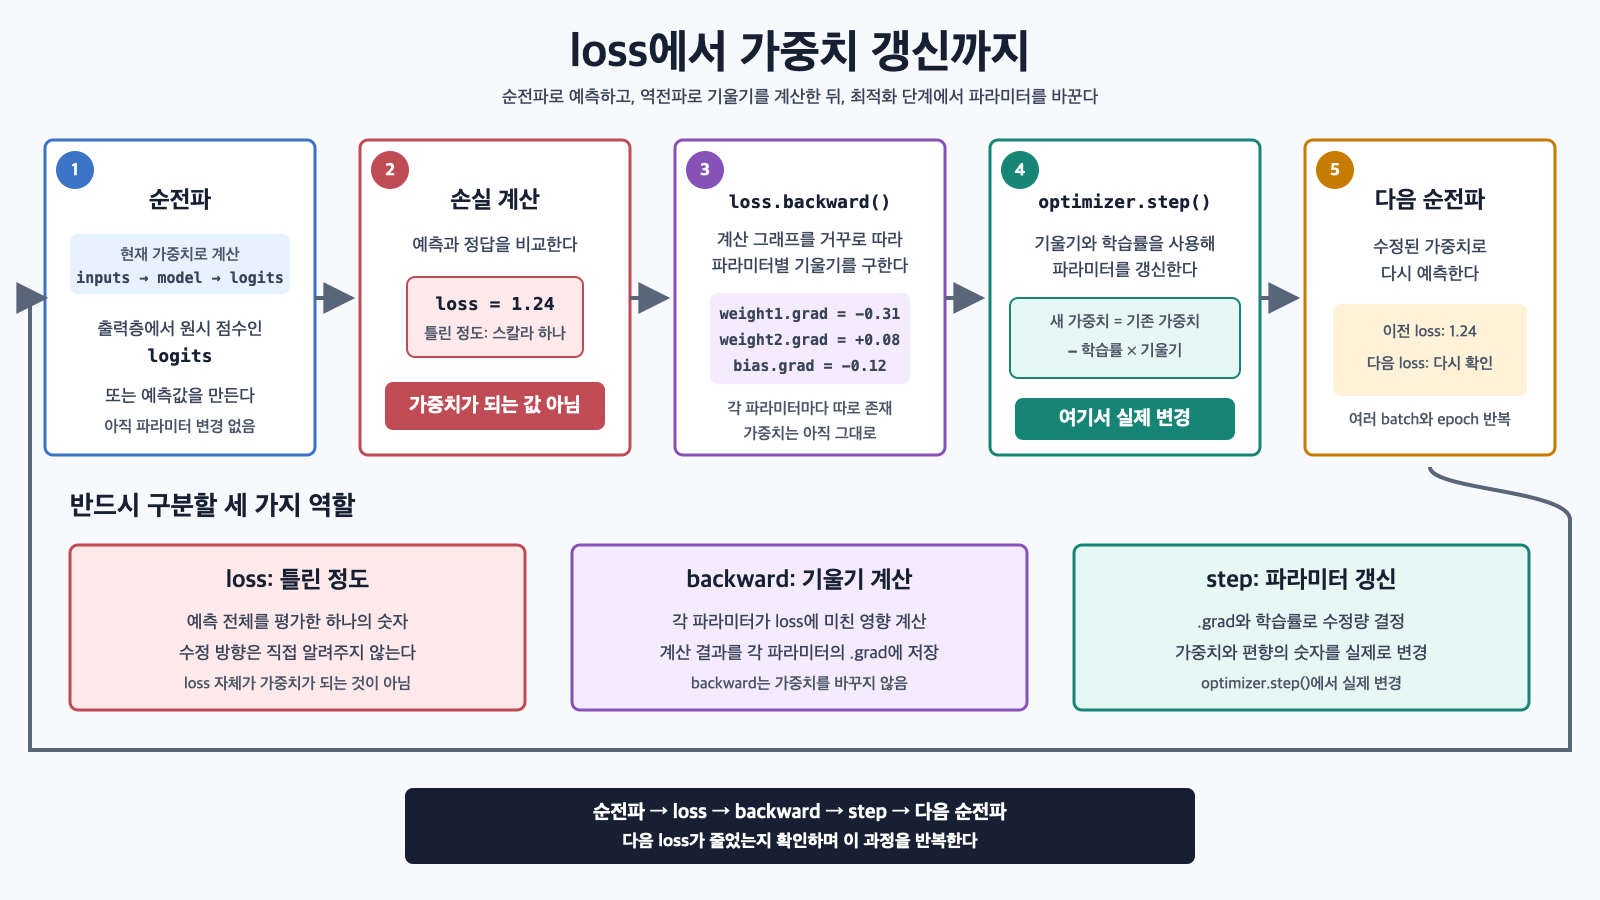

#### 1단계: 현재 가중치로 예측한다

입력 `x`가 모델을 통과한다. 순전파에서 현재 가중치와 편향을 사용해 logits 또는 예측값을 만든다.

#### 2단계: 손실함수로 loss를 계산한다

손실함수가 예측과 정답을 비교해 스칼라 loss 하나를 만든다. loss가 크다는 것은 현재 예측이 많이 틀렸다는 뜻이지만, 아직 수정 방향은 계산되지 않았다.

#### 3단계: 계산 그래프를 반대로 따라간다

PyTorch는 순전파 동안 `입력 → 층 → logits → loss`의 계산 관계를 기록한다. `loss.backward()`는 이 관계를 출력에서 입력 방향으로 따라간다.

#### 4단계: 파라미터마다 기울기를 계산한다

가중치가 여러 개라면 각 가중치마다 `∂loss/∂weight`가 따로 계산된다. 양의 기울기는 가중치를 키울 때 loss가 증가한다는 뜻이고, 음의 기울기는 가중치를 키울 때 loss가 감소한다는 뜻이다.

#### 5단계: optimizer가 파라미터를 수정한다

SGD는 기울기의 반대 방향으로 이동한다.

```text
새 가중치 = 기존 가중치 - 학습률 × 기울기
```

`backward()`는 기울기만 계산하고, 실제 가중치 변경은 `optimizer.step()`에서 일어난다.

#### 6단계: 수정된 가중치로 다시 예측한다

다음 순전파에서는 새로운 가중치를 사용한다. 같은 데이터의 loss가 줄었는지 확인하고, 이 과정을 여러 batch와 epoch에 걸쳐 반복한다.

#### 숫자 하나로 확인

입력 `x=2`, 정답 `10`, 가중치 `w=3`, 예측식 `예측=x×w`, 손실식 `loss=(예측-정답)²`라고 하자.

```text
예측 = 2 × 3 = 6
loss = (6 - 10)² = 16
기울기 = ∂loss/∂w = 2 × (6 - 10) × 2 = -16
새 가중치 = 3 - 0.1 × (-16) = 4.6
새 예측 = 2 × 4.6 = 9.2
새 loss = (9.2 - 10)² = 0.64
```

기울기가 `-16`이므로 가중치를 증가시키는 방향이 loss를 줄이는 방향이다. optimizer는 기울기의 반대 방향으로 이동하여 가중치를 `3`에서 `4.6`으로 수정한다.


In [2]:
# 목표: 가중치 하나의 loss, 기울기와 optimizer 갱신을 숫자로 확인한다.

# 입력값 2와 정답 10은 주어진 데이터이며 optimizer가 수정하는 대상이 아니다.
scalar_input = torch.tensor(2.0)
scalar_target = torch.tensor(10.0)

# requires_grad=True인 가중치만 미분 대상이 되어 `.grad`를 가질 수 있다.
scalar_weight = torch.tensor(3.0, requires_grad=True)

# SGD가 관리할 파라미터 목록에 scalar_weight를 전달한다.
# 학습률 0.1은 기울기를 실제 수정량으로 바꿀 때 곱하는 비율이다.
learning_rate = 0.1
scalar_optimizer = torch.optim.SGD([scalar_weight], lr=learning_rate)

# 1. 순전파: 현재 가중치 3을 사용하면 예측값은 2 × 3 = 6이다.
scalar_prediction = scalar_input * scalar_weight

# 2. 손실 계산: 제곱 오차 (6 - 10)²이므로 loss는 16이다.
scalar_loss = (scalar_prediction - scalar_target) ** 2

# backward 전의 가중치를 복사해 실제 변경 시점을 비교한다.
weight_before_backward = scalar_weight.detach().clone()

# 3. 역전파: loss를 가중치로 미분해 scalar_weight.grad에 저장한다.
# 현재 기울기는 2 × (예측 - 정답) × 입력 = 2 × (-4) × 2 = -16이다.
scalar_loss.backward()
calculated_gradient = scalar_weight.grad.detach().clone()
weight_after_backward = scalar_weight.detach().clone()

# SGD 공식으로 예상되는 새 가중치를 optimizer 실행 전에 직접 계산한다.
expected_weight = weight_before_backward - learning_rate * calculated_gradient

# 4. 파라미터 갱신: optimizer가 `기존 가중치 - 학습률 × 기울기`를 적용한다.
scalar_optimizer.step()
weight_after_step = scalar_weight.detach().clone()

# 5. 수정된 가중치로 다시 예측해 같은 데이터의 loss가 줄었는지 확인한다.
with torch.no_grad():
    next_prediction = scalar_input * scalar_weight
    next_loss = (next_prediction - scalar_target) ** 2

print("처음 예측:", scalar_prediction.item())
print("처음 loss:", scalar_loss.item())
print("계산된 기울기:", calculated_gradient.item())
print("backward 후 가중치:", weight_after_backward.item())
print("SGD 공식으로 예상한 가중치:", expected_weight.item())
print("optimizer.step 후 가중치:", weight_after_step.item())
print("다음 예측:", next_prediction.item())
print("다음 loss:", next_loss.item())

# 실행 결과:
# - 처음 예측 6, loss 16, 기울기 -16이 출력된다.
# - backward 직후 가중치는 3으로 유지되고, step 직후에는 4.6으로 변경된다.
# - 수정 후 예측은 약 9.2, loss는 약 0.64로 감소한다.

# 알 수 있는 것:
# - loss 16이 가중치에 직접 더해지거나 빼지는 것이 아니라, loss를 미분한 기울기 -16이 갱신에 사용된다.
# - backward는 `.grad`를 계산하고 step이 가중치를 변경한다는 두 단계의 역할을 구분할 수 있다.


처음 예측: 6.0
처음 loss: 16.0
계산된 기울기: -16.0
backward 후 가중치: 3.0
SGD 공식으로 예상한 가중치: 4.599999904632568
optimizer.step 후 가중치: 4.599999904632568
다음 예측: 9.199999809265137
다음 loss: 0.6400002837181091


### 실제 신경망에서 한 번의 학습 단계 확인

앞에서는 가중치 하나로 계산했다. 이제 여러 가중치와 편향을 가진 `ReviewNet`에서 같은 흐름을 실행하고, `backward()` 직후와 `step()` 직후의 가중치를 따로 비교한다.


In [3]:
# 목표: 실제 신경망에서 backward와 optimizer.step의 역할을 분리해 확인한다.

# 정답 2는 세 번째 클래스를 의미하며 CrossEntropyLoss의 정답 dtype은 long이다.
review_target = torch.tensor([2], dtype=torch.long)

# CrossEntropyLoss는 logits와 정답 클래스 번호를 비교해 loss 하나를 계산한다.
criterion = nn.CrossEntropyLoss()

# SGD는 각 파라미터를 `기존 값 - 학습률 × 기울기`로 갱신한다.
LEARNING_RATE = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

# 여러 파라미터 중 첫 번째 은닉층의 가중치를 대표로 관찰한다.
# detach().clone()은 계산 그래프와 분리된 복사본을 만들어 이후 변경의 영향을 받지 않게 한다.
weight_before = model.hidden_layer.weight.detach().clone()

# 1. 이전 학습 단계의 기울기가 누적되지 않도록 `.grad`를 초기화한다.
optimizer.zero_grad()

# 2. 순전파: 현재 가중치와 편향으로 클래스별 logits를 계산한다.
_, _, logits_before = model(review_inputs)

# 3. 손실 계산: logits와 정답을 비교해 스칼라 loss 하나를 만든다.
loss_before = criterion(logits_before, review_target)

# 4. 역전파: 각 파라미터에 대한 `∂loss/∂파라미터`를 계산해 `.grad`에 저장한다.
# 이 시점에는 기울기만 만들어지고 가중치는 아직 바뀌지 않는다.
loss_before.backward()
weight_after_backward = model.hidden_layer.weight.detach().clone()
weight_gradient = model.hidden_layer.weight.grad.detach().clone()

# SGD 공식으로 첫 번째 은닉층 가중치의 예상 갱신 결과를 직접 계산한다.
expected_weight_after_step = weight_before - LEARNING_RATE * weight_gradient

# 5. optimizer가 모든 학습 파라미터의 `.grad`를 읽어 실제 값을 갱신한다.
optimizer.step()
weight_after_step = model.hidden_layer.weight.detach().clone()

# 수정된 파라미터로 같은 샘플을 다시 예측하되, 비교만 하므로 계산 그래프는 만들지 않는다.
with torch.no_grad():
    _, _, logits_after = model(review_inputs)
    loss_after = criterion(logits_after, review_target)

print("학습 전 loss:", loss_before.item())
print("첫 번째 층 기울기 크기:", weight_gradient.norm().item())
print("backward가 가중치를 변경했는가:", not torch.equal(weight_before, weight_after_backward))
print("step이 가중치를 변경했는가:", not torch.equal(weight_before, weight_after_step))
print("SGD 공식과 실제 갱신이 같은가:", torch.allclose(expected_weight_after_step, weight_after_step))
print("한 번 갱신 후 loss:", loss_after.item())

# 실행 결과:
# - 기울기 크기는 0이 아닌 값으로 출력된다.
# - backward의 가중치 변경 여부는 False, step의 변경 여부와 SGD 공식 비교는 True로 출력된다.
# - 같은 샘플의 갱신 후 loss는 일반적으로 갱신 전보다 작아진다.

# 알 수 있는 것:
# - loss.backward()는 각 파라미터의 `.grad`를 계산하지만 파라미터 값은 바꾸지 않는다.
# - optimizer.step()이 학습률과 `.grad`를 사용해 실제 가중치와 편향을 수정한다.
# - loss가 증가하거나 NaN이면 학습률, 입력값 범위, logits shape와 손실함수 조합을 점검한다.


학습 전 loss: 1.5354511737823486
첫 번째 층 기울기 크기: 0.35873502492904663
backward가 가중치를 변경했는가: False
step이 가중치를 변경했는가: True
SGD 공식과 실제 갱신이 같은가: True
한 번 갱신 후 loss: 1.2665551900863647


### PyTorch 학습 순서 한 줄 복습

```python
optimizer.zero_grad()                 # 이전 .grad 초기화
logits = model(inputs)                # 현재 가중치로 순전파
loss = criterion(logits, targets)     # 예측과 정답을 loss 하나로 계산
loss.backward()                       # 각 파라미터의 ∂loss/∂파라미터 계산
optimizer.step()                      # 학습률과 .grad로 파라미터 갱신
```

반드시 구분해야 하는 내용은 다음과 같다.

- `loss`는 모델이 얼마나 틀렸는지를 나타내는 숫자이다.
- `loss.backward()`는 loss 숫자를 가중치로 바꾸는 것이 아니라, 각 가중치에 대한 loss의 기울기를 계산한다.
- 계산된 기울기는 각 파라미터의 `.grad`에 저장된다.
- `optimizer.step()`은 `.grad`를 읽어 가중치와 편향을 수정한다.
- `optimizer.zero_grad()`는 다음 batch에서 이전 기울기가 섞이지 않도록 초기화한다.


## 4. CNN 복습: 이미지에서 특징을 찾는 과정

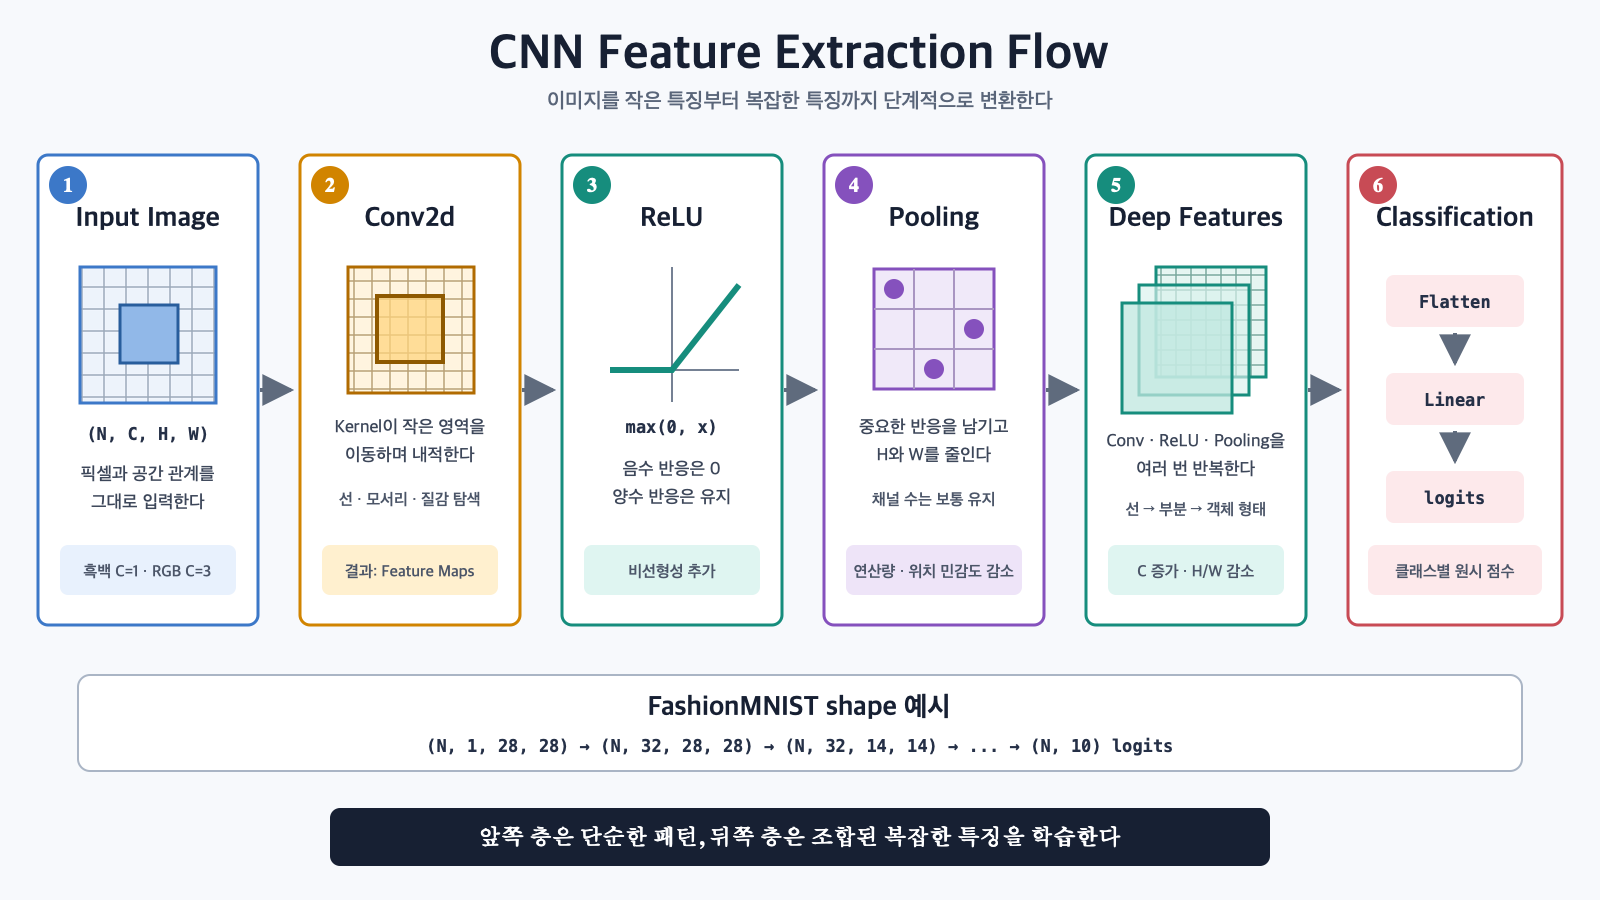

CNN은 이미지를 바로 한 줄로 펼치지 않고 작은 영역을 반복해서 확인한다. 앞쪽 합성곱층은 선과 모서리 같은 단순한 패턴을 찾고, 뒤쪽 층은 이를 조합해 객체의 부분과 전체 형태를 표현한다.

### 이미지 Tensor

- PyTorch CNN 입력은 `(batch, channel, height, width)` 순서이다.
- 흑백 이미지는 channel이 1이고 RGB 이미지는 channel이 3이다.

### Feature Map

- Kernel이 입력의 각 위치에서 특정 특징에 얼마나 반응했는지 나타내는 결과이다.
- 합성곱층이 깊어질수록 채널 수는 늘고 높이와 너비는 줄어드는 경우가 많다.

### ReLU와 Pooling

- ReLU는 음수 반응을 0으로 만들어 비선형성을 추가하며 Tensor shape는 바꾸지 않는다.
- MaxPool2d는 작은 영역의 가장 큰 반응만 남겨 높이와 너비를 줄인다.
- Pooling은 일반적으로 채널 수를 바꾸지 않는다.


### Kernel, Padding, Stride

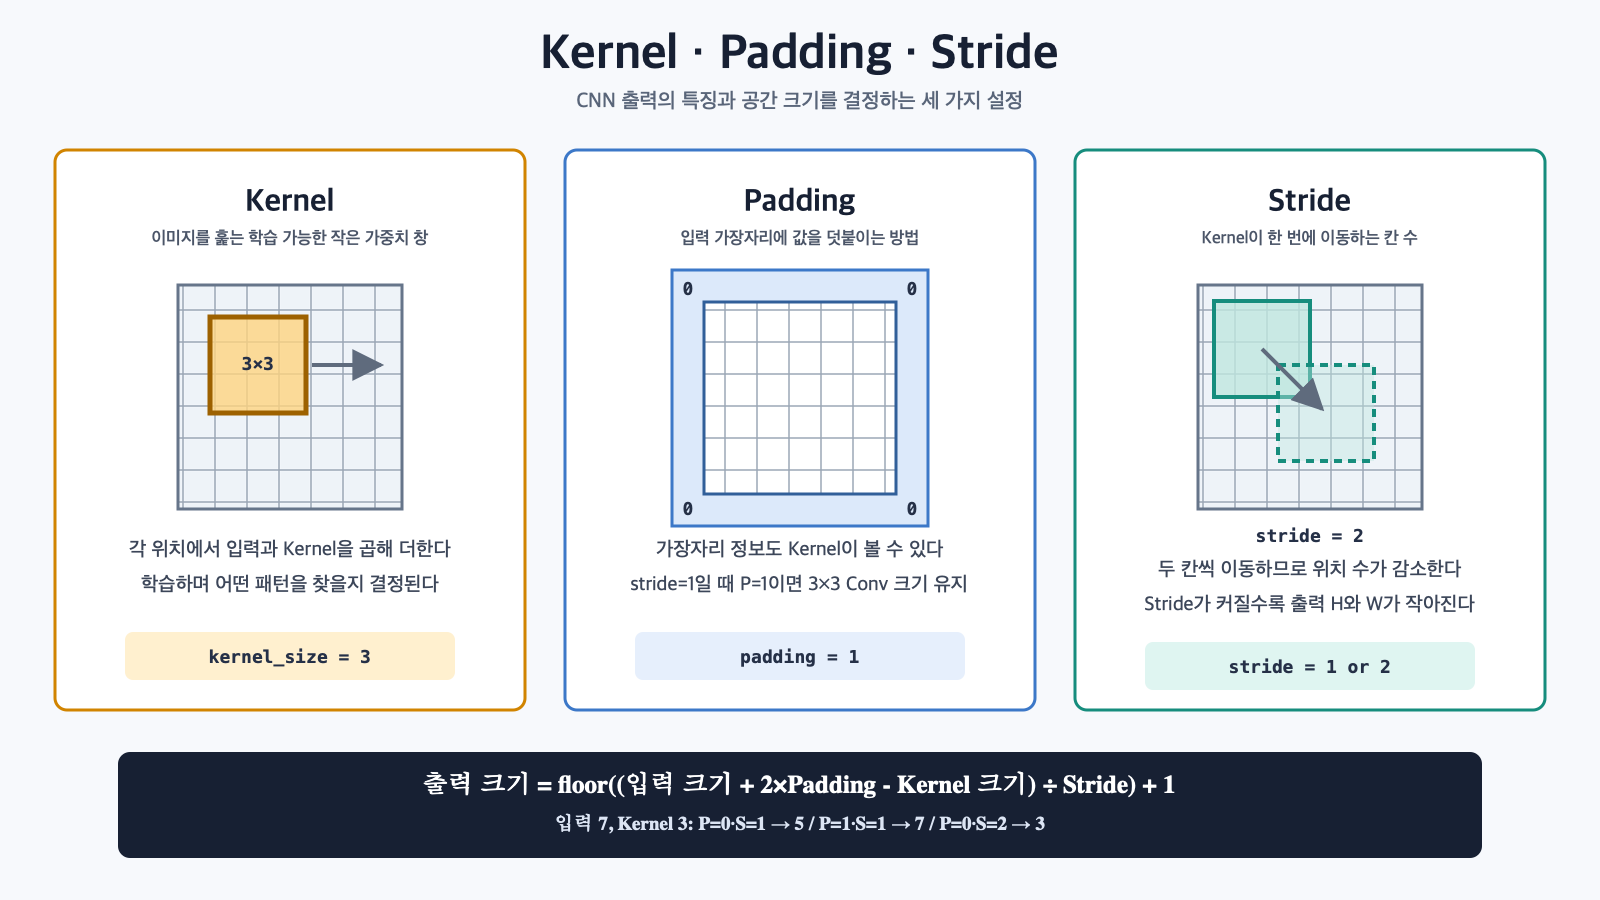

- **Kernel**은 입력의 작은 영역과 내적하며 학습할 특징을 찾는 가중치 창이다.
- **Padding**은 입력 가장자리에 값을 덧붙여 가장자리 정보를 사용하고 출력 크기를 조절한다.
- **Stride**는 Kernel이 한 번에 이동하는 칸 수이며, 값이 커질수록 출력의 높이와 너비가 작아진다.

세 값은 다음 출력 크기 공식에 함께 사용된다.

```text
출력 크기 = floor((입력 크기 + 2×Padding - Kernel 크기) ÷ Stride) + 1
```


### 흑백 1채널과 RGB 3채널의 Kernel 차이

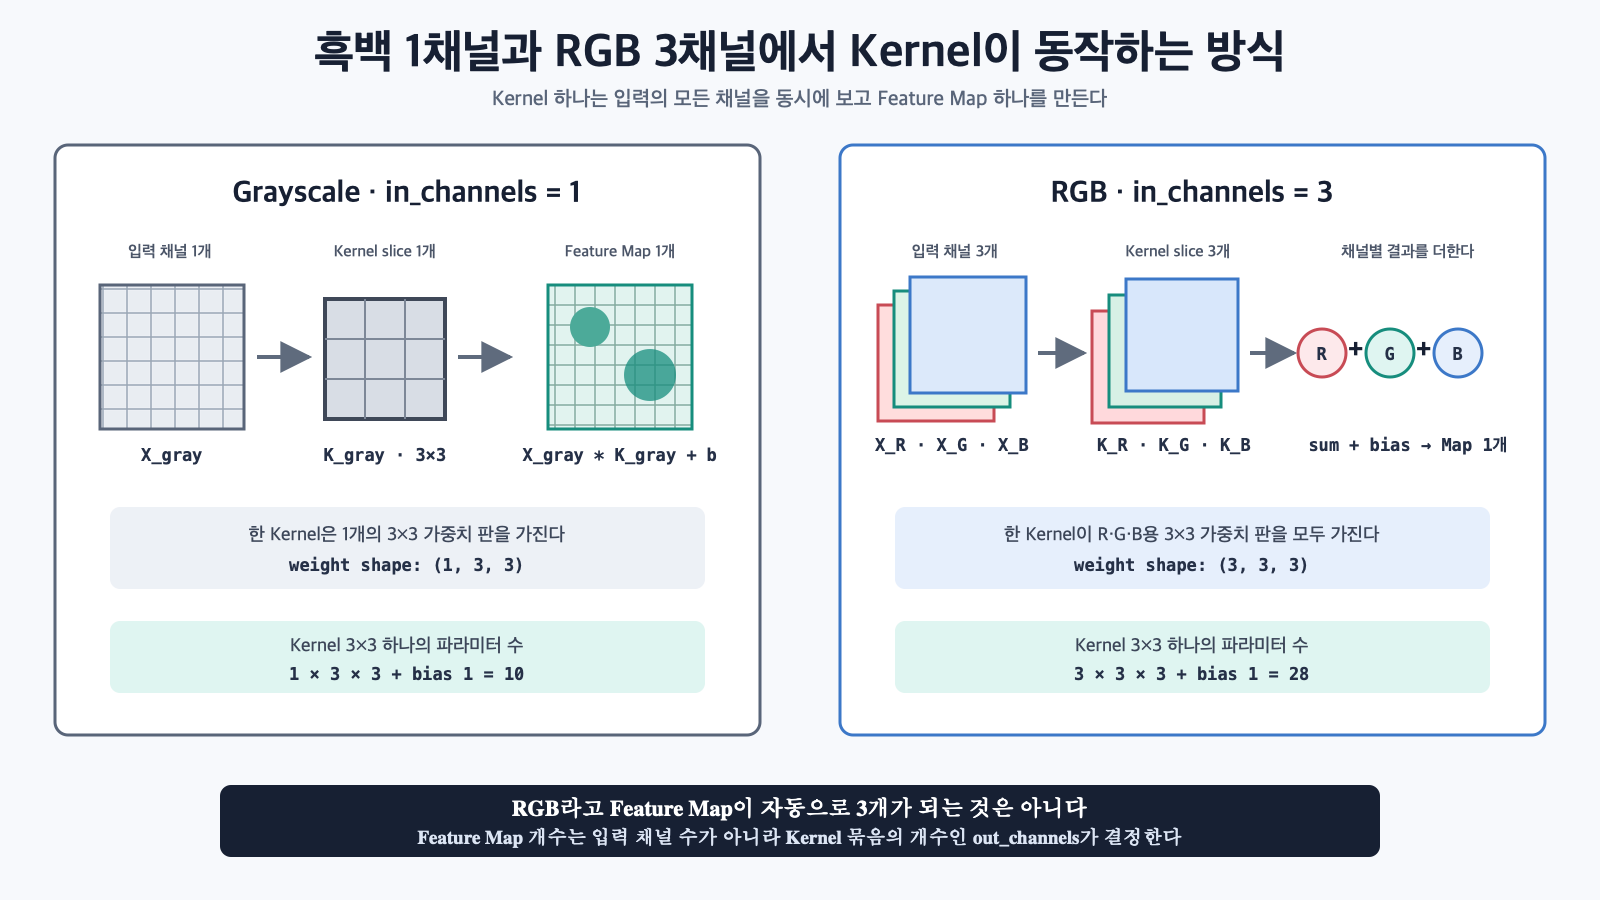

- 흑백 입력의 Filter 하나는 2차원 Kernel slice 1개를 가진다.
- RGB 입력의 Filter 하나는 R, G, B용 Kernel slice 3개를 가진다.
- 각 채널의 합성곱 결과를 모두 더하고 bias를 더하면 출력 Feature Map 하나가 만들어진다.
- RGB 입력이라고 출력 Feature Map이 자동으로 3개가 되는 것은 아니다. Feature Map 개수는 `out_channels`가 결정한다.

```text
RGB Filter 하나의 출력
= R 입력 * R용 Kernel slice
+ G 입력 * G용 Kernel slice
+ B 입력 * B용 Kernel slice
+ bias
= Feature Map 1개
```

> 교재나 라이브러리 설명에서는 Kernel과 Filter를 같은 의미로 사용하기도 한다. 이 노트북에서는 구조를 쉽게 구분하기 위해 채널별 2차원 가중치를 **Kernel slice**, 모든 입력 채널의 slice를 묶은 것을 **Filter**라고 부른다.


### Filter Bank, in_channels와 out_channels

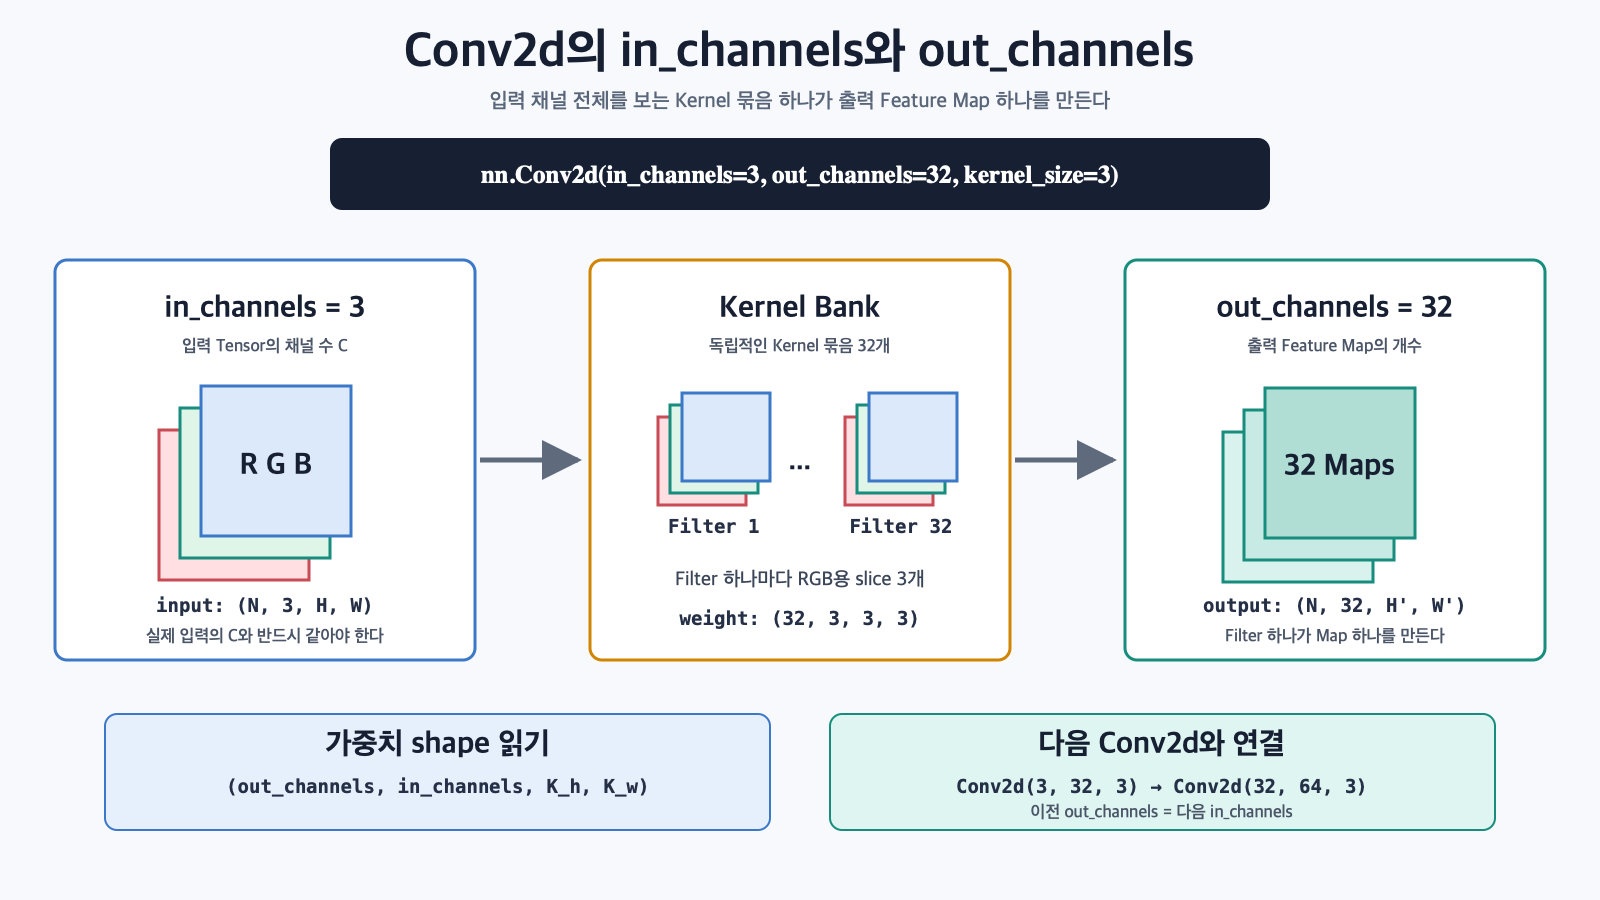

#### 먼저 batch와 channel을 구분한다

입력 shape가 `(32, 3, H, W)`라면 첫 번째 32는 동시에 처리하는 이미지 수이고, 3은 이미지 한 장의 RGB 채널 수이다.

```text
(32, 3, H, W)
  ↑  ↑
batch RGB channel
```

- `batch_size=32`는 이미지가 32장이라는 뜻이며 Kernel이나 Filter 개수를 결정하지 않는다.
- 같은 Filter Bank가 batch에 들어 있는 32장 모두에 반복 적용된다.
- `in_channels=3`은 이미지 한 장마다 R, G, B 채널 3개가 있다는 뜻이다.

#### Filter와 Filter Bank

- **Kernel slice**: 입력 채널 하나를 담당하는 2차원 가중치이다.
- **Filter**: 모든 입력 채널의 Kernel slice를 묶은 것이다. Filter 하나가 출력 Feature Map 하나를 만든다.
- **Filter Bank 또는 Kernel Bank**: 합성곱층이 가지고 있는 Filter 전체 묶음이다.

`Conv2d(3, 32, 3)`은 다음 구조를 가진다.

```text
Filter 1  = RGB용 Kernel slice 3개 → Feature Map 1
Filter 2  = RGB용 Kernel slice 3개 → Feature Map 2
...
Filter 32 = RGB용 Kernel slice 3개 → Feature Map 32

Filter 32개 전체 = Filter Bank
```

따라서 구조상 `32개 Filter × 채널별 slice 3개`가 있으며, 같은 32개 Filter를 입력 이미지마다 다시 사용한다.

#### in_channels와 out_channels

- `in_channels`는 현재 입력 Tensor의 채널 수이다. 첫 합성곱층은 흑백이면 1, RGB이면 3으로 지정한다.
- `out_channels`는 Filter의 개수이며 출력 Feature Map의 채널 수가 된다.
- `Conv2d(3, 32, 3)`의 가중치 shape는 `(32, 3, 3, 3)`이다. 순서대로 출력 채널, 입력 채널, Kernel 높이, Kernel 너비를 의미한다.
- 다음 합성곱층의 `in_channels`는 이전 합성곱층의 `out_channels`와 같아야 한다.

```text
입력:  (32, 3, H, W)
Conv2d(3, 32, 3)
출력:  (32, 32, H_out, W_out)

첫 번째 32 = 입력 이미지 수
두 번째 32 = 이미지 한 장마다 만들어진 Feature Map 수
```


### 합성곱, ReLU와 pooling의 shape 변화

작은 흑백 이미지 batch를 `Conv2d → ReLU → MaxPool2d` 순서로 통과시켜 shape 변화를 확인한다.


In [4]:
# 목표: CNN의 합성곱, ReLU와 pooling을 통과할 때 Tensor shape와 값이 어떻게 변하는지 확인한다.

# 샘플 1개, 흑백 채널 1개, 높이와 너비가 6인 입력 Tensor를 만든다.
cnn_input = torch.linspace(-1, 1, steps=36).reshape(1, 1, 6, 6)

# in_channels=1은 흑백 입력, out_channels=2는 커널 2개를 의미한다.
# kernel_size=3, stride=1, padding=1이므로 높이와 너비 6이 유지된다.
conv = nn.Conv2d(
    in_channels=1,
    out_channels=2,
    kernel_size=3,
    stride=1,
    padding=1,
)

# ReLU는 shape를 유지하면서 음수를 0으로 만든다.
relu = nn.ReLU()

# 2×2 영역에서 최댓값을 고르고 두 칸씩 이동하므로 높이와 너비가 절반으로 줄어든다.
pool = nn.MaxPool2d(kernel_size=2, stride=2)

feature_map = conv(cnn_input)
activated_map = relu(feature_map)
pooled_map = pool(activated_map)

print("입력 shape:", tuple(cnn_input.shape))
print("합성곱 후 shape:", tuple(feature_map.shape))
print("ReLU 후 shape:", tuple(activated_map.shape))
print("pooling 후 shape:", tuple(pooled_map.shape))
print("합성곱 결과의 음수 개수:", (feature_map < 0).sum().item())
print("ReLU 결과의 음수 개수:", (activated_map < 0).sum().item())

# 실행 결과:
# - shape가 `(1,1,6,6) → (1,2,6,6) → (1,2,6,6) → (1,2,3,3)` 순서로 출력된다.
# - 합성곱 결과에는 음수가 있을 수 있지만 ReLU 결과의 음수 개수는 0이다.
# 알 수 있는 것:
# - Conv2d의 out_channels가 출력 채널 수를 결정하고 padding=1이 공간 크기를 유지한다.
# - ReLU는 shape를 바꾸지 않으며 MaxPool2d는 채널을 유지한 채 높이와 너비를 줄인다.


입력 shape: (1, 1, 6, 6)
합성곱 후 shape: (1, 2, 6, 6)
ReLU 후 shape: (1, 2, 6, 6)
pooling 후 shape: (1, 2, 3, 3)
합성곱 결과의 음수 개수: 28
ReLU 결과의 음수 개수: 0


### 합성곱 출력 크기 공식

높이와 너비 각각에 다음 공식을 적용한다.

```text
출력 크기 = 내림((입력 크기 + 2×패딩 - 커널 크기) ÷ 보폭) + 1
```

입력 크기 6, 커널 3, padding 1, stride 1이면 출력 크기는 6이다.

```text
(6 + 2×1 - 3) ÷ 1 + 1 = 6
```

CNN에서는 공식 암기보다 코드 실행 후 실제 shape가 예상과 일치하는지 확인하는 습관이 중요하다.


## 5. 자주 혼동하는 개념

### loss, 가중치와 기울기

- loss는 현재 예측이 얼마나 틀렸는지 나타내는 하나의 숫자이다.
- 가중치는 모델이 현재 가지고 있는 학습 대상 숫자이다.
- 기울기는 각 가중치를 바꿀 때 loss가 변하는 방향과 민감도를 나타낸다.
- loss 값 자체를 가중치에서 빼는 것이 아니라 `학습률 × 기울기`를 사용한다.

### backward와 optimizer.step

- `backward()`는 각 파라미터의 `.grad`를 계산한다.
- `backward()` 직후에는 가중치가 그대로이다.
- `optimizer.step()`을 호출할 때 가중치와 편향이 실제로 변경된다.

### 활성화 함수와 손실함수

- 활성화 함수는 모델 내부에서 입력 표현을 변환한다.
- 손실함수는 모델의 최종 예측과 정답을 비교한다.

### logits와 확률

- logits는 출력층이 만든 원시 점수이다.
- 확률은 logits에 Sigmoid 또는 Softmax를 적용해 해석하기 쉽게 만든 값이다.
- `CrossEntropyLoss`와 `BCEWithLogitsLoss`에는 확률이 아니라 logits를 전달한다.

### 합성곱과 pooling

- 합성곱은 학습 가능한 커널로 특징을 찾는다.
- pooling은 정해진 규칙으로 특징 지도의 공간 크기를 줄인다.


## 최종 핵심 문장

1. 딥러닝 모델은 입력을 여러 층으로 변환해 logits를 만든다.
2. 각 층의 가중치와 편향은 학습으로 수정되는 파라미터이다.
3. 손실함수는 예측과 정답의 차이를 loss 하나로 계산한다.
4. `loss.backward()`는 loss를 각 파라미터로 편미분한 기울기를 `.grad`에 저장한다.
5. `backward()`만 실행하면 가중치는 바뀌지 않는다.
6. `optimizer.step()`이 학습률과 기울기를 이용해 가중치와 편향을 갱신한다.
7. CNN은 합성곱으로 특징을 찾고 ReLU로 비선형성을 추가하며 pooling으로 공간 크기를 줄인다.

```text
입력 → 순전파 → logits → loss → backward로 기울기 계산 → optimizer로 가중치 갱신 → 다시 순전파
```
